In [1]:
!pip install "zarr>=3"
import zarr
print(zarr.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.5 MB/s eta 0:00:00
3.1.3


In [2]:
!python --version

Python 3.11.13


In [3]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import nibabel as nib
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from tqdm import tqdm
import cv2 as cv
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import argparse
import matplotlib.pyplot as plt
import random
import torchvision.models as models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
df = pd.read_csv('/kaggle/input/all-metrics-eyeq/final_metrics.csv')

In [6]:
df.columns

Index(['name', 'label', 'total_variation', 'brisque', 'psnr', 'ssim',
       'multi_scale_ssim', 'information_weighted_ssim', 'vif_p', 'fsim',
       'srsim', 'gmsd', 'multi_scale_gmsd', 'vsi', 'dss', 'haarpsi', 'mdsi',
       'vessel_density', 'vessel_length', 'vessel_contrast',
       'vessel_sharpness'],
      dtype='object')

In [7]:
import os
import json
import zarr
from zarr.storage import LocalStore
import numpy as np

with open('/kaggle/input/eyeq-1280/zarr/filenames.json', 'r') as file:
    files = json.load(file)
    
ZARR_OUT_DIR = r"/kaggle/input/eyeq-1280/zarr"  

name2idx_path = os.path.join(ZARR_OUT_DIR, "name2idx.json")
if not os.path.exists(name2idx_path):
    raise FileNotFoundError("name2idx.json not found. Did you run the writer that creates it?")

with open(name2idx_path, "r", encoding="utf-8") as f:
    name2idx = json.load(f)

store = LocalStore(ZARR_OUT_DIR)
root = zarr.open(store=store, mode="r")
imgs = root["images"]  

def read_image_by_filename(fname):
    idx = name2idx.get(fname)
    if idx is None:
        raise KeyError(f"Filename {fname} not found in name2idx.json")
    chunk = imgs[idx]  
    return np.array(chunk, dtype=np.uint8)

In [8]:
'''
class PTImageDataset(Dataset):
    def __init__(self, dataframe, folder1, folder2, tabular_csv, device='cpu'):
        self.df = dataframe.reset_index(drop=True)

        tabular_df = pd.read_csv(tabular_csv)
        if "label" in tabular_df.columns:
            tabular_df = tabular_df.drop(columns=["label"])  

        feature_cols = [c for c in tabular_df.columns if c != "name"]
        scaler = MinMaxScaler()
        tabular_df[feature_cols] = scaler.fit_transform(tabular_df[feature_cols])

        self.tabular_map = {
            os.path.splitext(row["name"])[0] + ".jpeg": torch.tensor(
                row[feature_cols].values.astype(np.float32)
            )
            for _, row in tabular_df.iterrows()
        }

        all_pt_files = []
        for folder in [folder1, folder2]:
            for fname in os.listdir(folder):
                if fname.endswith('.pt'):
                    all_pt_files.append(os.path.join(folder, fname))

        self.path_map = {
            os.path.splitext(os.path.basename(path))[0]: path
            for path in all_pt_files
        }

        self.filepaths, self.labels, self.tabular_feats = [], [], []
        for idx, row in self.df.iterrows():
            img_name = row['image']   
            base_name = os.path.splitext(img_name)[0] + ".jpeg"  

            if base_name not in self.path_map:
                print(f"Skipping {base_name}: .pt file not found.")
                continue
            if base_name not in self.tabular_map:
                continue

            self.filepaths.append(self.path_map[base_name])
            self.labels.append(row['quality'])
            self.tabular_feats.append(self.tabular_map[base_name])

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        filepath = self.filepaths[idx]
        label = self.labels[idx]
        tabular = self.tabular_feats[idx]

        tensor = torch.load(filepath, map_location="cpu")

        return tensor, torch.tensor(label, dtype=torch.long), tabular
        
'''

'\nclass PTImageDataset(Dataset):\n    def __init__(self, dataframe, folder1, folder2, tabular_csv, device=\'cpu\'):\n        self.df = dataframe.reset_index(drop=True)\n\n        tabular_df = pd.read_csv(tabular_csv)\n        if "label" in tabular_df.columns:\n            tabular_df = tabular_df.drop(columns=["label"])  \n\n        feature_cols = [c for c in tabular_df.columns if c != "name"]\n        scaler = MinMaxScaler()\n        tabular_df[feature_cols] = scaler.fit_transform(tabular_df[feature_cols])\n\n        self.tabular_map = {\n            os.path.splitext(row["name"])[0] + ".jpeg": torch.tensor(\n                row[feature_cols].values.astype(np.float32)\n            )\n            for _, row in tabular_df.iterrows()\n        }\n\n        all_pt_files = []\n        for folder in [folder1, folder2]:\n            for fname in os.listdir(folder):\n                if fname.endswith(\'.pt\'):\n                    all_pt_files.append(os.path.join(folder, fname))\n\n        self

In [9]:
class ZarrImageDataset(Dataset):
    def __init__(self, dataframe, tabular_csv):
        self.df = dataframe.reset_index(drop=True)

        # preprocess tabular
        tabular_df = pd.read_csv(tabular_csv)
        if "label" in tabular_df.columns:
            tabular_df = tabular_df.drop(columns=["label"])  

        feature_cols = [c for c in tabular_df.columns if c != "name"]
        scaler = MinMaxScaler()
        tabular_df[feature_cols] = scaler.fit_transform(tabular_df[feature_cols])

        self.tabular_map = {
            os.path.splitext(row["name"])[0] + ".jpeg": torch.tensor(
                row[feature_cols].values.astype(np.float32)
            )
            for _, row in tabular_df.iterrows()
        }

        self.filepaths, self.labels, self.tabular_feats = [], [], []
        for _, row in self.df.iterrows():
            img_name = row['image']   
            base_name = os.path.splitext(img_name)[0] + ".jpeg"  

            if base_name not in name2idx:   # check Zarr index
                print(f"Skipping {base_name}: not in Zarr store.")
                continue
            if base_name not in self.tabular_map:
                continue

            self.filepaths.append(base_name)
            self.labels.append(row['quality'])
            self.tabular_feats.append(self.tabular_map[base_name])

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        fname = self.filepaths[idx]
        label = self.labels[idx]
        tabular = self.tabular_feats[idx]

        img_np = read_image_by_filename(fname)  
        tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0  

        return tensor, torch.tensor(label, dtype=torch.long), tabular

In [10]:

label1 = pd.read_csv("/kaggle/input/label-for-eyeq/Label_EyeQ_train (1).csv").drop(columns="Unnamed: 0")
label2 = pd.read_csv("/kaggle/input/label-for-eyeq/Label_EyeQ_test (1).csv").drop(columns="Unnamed: 0")
label = pd.concat([label1, label2], ignore_index=True)

tabular_csv = "/kaggle/input/all-metrics-eyeq/final_metrics.csv"

dataset = ZarrImageDataset(label, tabular_csv)
dataloader = DataLoader(dataset, batch_size=4, shuffle=False)

for img, lbl, feats in dataloader:
    print("Image batch shape:", img.shape)         # [B, C, H, W]
    print("Labels:", lbl.shape, lbl)               # [B]
    print("Tabular features shape:", feats.shape)  # [B, num_features]
    break

Image batch shape: torch.Size([4, 3, 1280, 1280])
Labels: torch.Size([4]) tensor([0, 0, 2, 2])
Tabular features shape: torch.Size([4, 19])


In [11]:
def split_dataset(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    assert train_ratio + val_ratio + test_ratio == 1, "Ratios must sum to 1"
    df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
    train_end = int(len(df) * train_ratio)
    val_end = train_end + int(len(df) * val_ratio)
    return df_shuffled[:train_end], df_shuffled[train_end:val_end], df_shuffled[val_end:]

df = dataset.df
train_df, val_df, test_df = split_dataset(df)

In [12]:
print("Train class counts:")
print(train_df['quality'].value_counts())

print("\nValidation class counts:")
print(val_df['quality'].value_counts())

print("\nTest class counts:")
print(test_df['quality'].value_counts())

Train class counts:
quality
0    11837
1     4469
2     3848
Name: count, dtype: int64

Validation class counts:
quality
0    2514
1     979
2     825
Name: count, dtype: int64

Test class counts:
quality
0    2467
1     986
2     867
Name: count, dtype: int64


In [13]:
def show_sample_images(df, dataset, title):
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    fig.suptitle(title, fontsize=16)
    sample_indices = random.sample(range(len(df)), 5)
    for i, idx in enumerate(sample_indices):
        img, label, tab = dataset[idx]
        img = img.permute(1, 2, 0).cpu().numpy()
        axes[i].imshow(img)
        axes[i].set_title(f"Class: {label.item()}")
        axes[i].axis("off")
    plt.show()

In [14]:
train_dataset = ZarrImageDataset(train_df, tabular_csv)
val_dataset   = ZarrImageDataset(val_df,tabular_csv)
test_dataset  = ZarrImageDataset(test_df,tabular_csv)

In [15]:
print(f"Training images:   {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images:       {len(test_dataset)}")

total_images = len(train_dataset) + len(val_dataset) + len(test_dataset)
print(f"Total images:      {total_images}")


Training images:   19999
Validation images: 4282
Test images:       4283
Total images:      28564


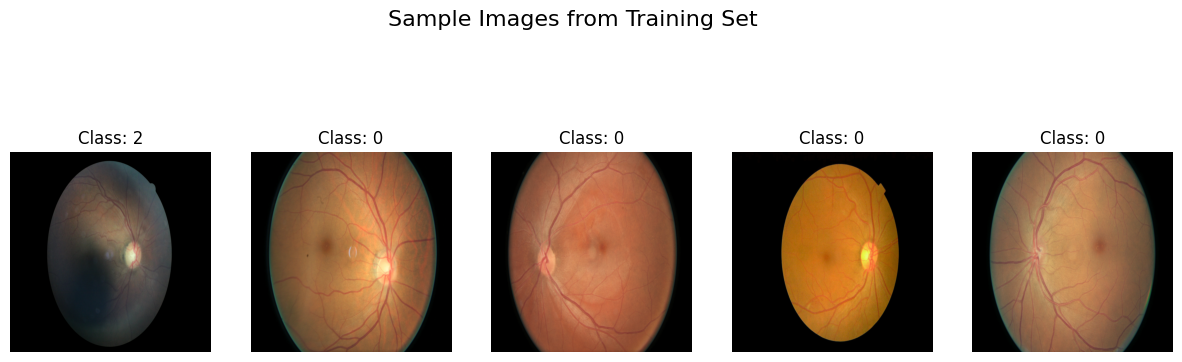

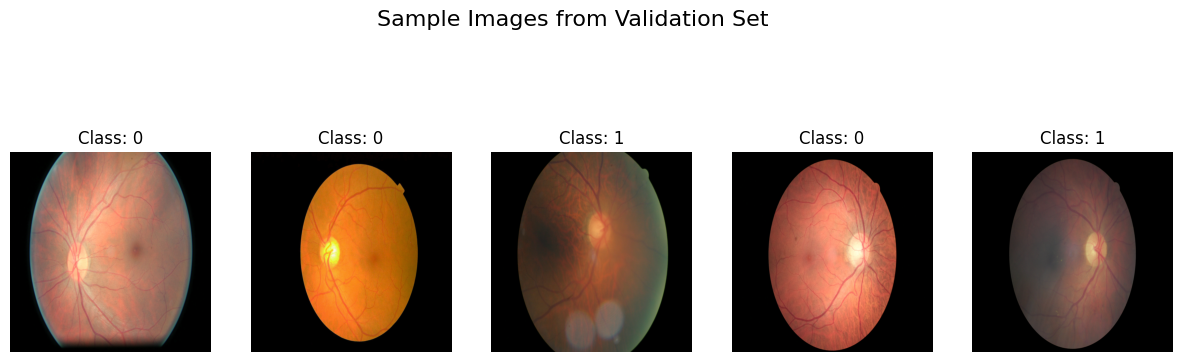

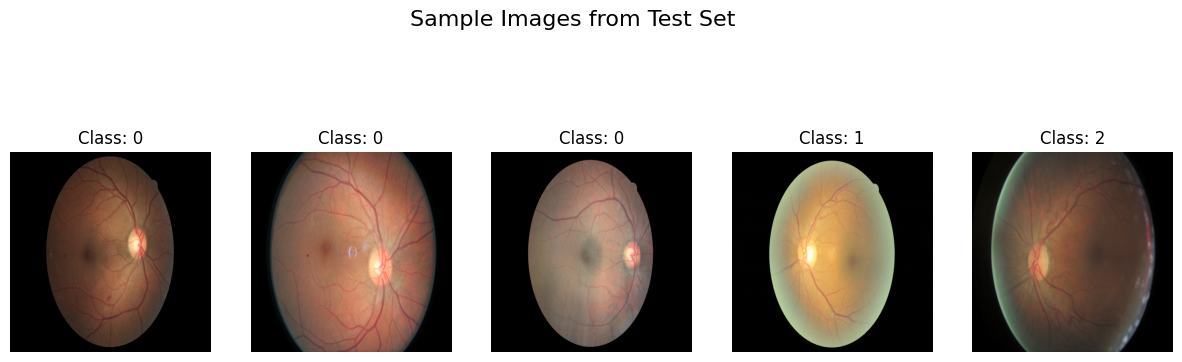

In [16]:
show_sample_images(train_df, train_dataset, "Sample Images from Training Set")
show_sample_images(val_df, val_dataset, "Sample Images from Validation Set")
show_sample_images(test_df, test_dataset, "Sample Images from Test Set")

In [17]:
class VGGEncoder(nn.Module):
    def __init__(self, pretrained=True):
        super(VGGEncoder, self).__init__()
        vgg_features = models.vgg16(pretrained=pretrained).features
        self.encoder = nn.Sequential(*list(vgg_features.children())[:23])  # Up to conv4_3

    def forward(self, x):
        return self.encoder(x)

In [18]:
def stitch_quadrants(qs):
    # qs = [q1, q2, q3, q4], each [B, 3, 640, 640]
    q1, q2, q3, q4 = qs
    top = torch.cat((q1, q2), dim=3)   # concat width
    bottom = torch.cat((q3, q4), dim=3)
    return torch.cat((top, bottom), dim=2)  # concat height

In [19]:
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, latent_list):
        decoded_patches = [self.decoder(lat) for lat in latent_list]
        # each decoded = [B, 3, 640, 640]
        return stitch_quadrants(decoded_patches)  # -> [B, 3, 1280, 1280]

In [20]:
class LatentClassifier(nn.Module):
    def __init__(self, num_classes=3, tabular_dim=19):
        super(LatentClassifier, self).__init__()
        
        self.tabular_branch = nn.Sequential(
            nn.Linear(tabular_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
        )

        self.cnn_pool = nn.AdaptiveAvgPool2d((7, 7))
        self.flatten = nn.Flatten()

        cnn_out_dim = (512 * 4) * 7 * 7  

        fusion_dim = cnn_out_dim + 128
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, latent_fused, tabular_feats):
        cnn_feats = self.cnn_pool(latent_fused)
        cnn_feats = self.flatten(cnn_feats)

        tab_feats = self.tabular_branch(tabular_feats)

        combined = torch.cat((cnn_feats, tab_feats), dim=1)

        return self.fusion(combined)

In [21]:
def split_into_quadrants(x):
    # x shape: [B, 3, 1280, 1280]
    B, C, H, W = x.shape
    assert H == 1280 and W == 1280, "Input must be 1280x1280"

    x1 = x[:, :, :H//2, :W//2]          
    x2 = x[:, :, :H//2, W//2:]          
    x3 = x[:, :, H//2:, :W//2]          
    x4 = x[:, :, H//2:, W//2:]          
    return [x1, x2, x3, x4]


In [22]:
class MODEL(nn.Module):
    def __init__(self, num_classes=3, pretrained=True, tabular_dim=19):
        super(MODEL, self).__init__()
        self.encoder = VGGEncoder(pretrained=pretrained)
        self.decoder = Decoder()
        self.classifier = LatentClassifier(num_classes=num_classes, tabular_dim=tabular_dim)

    def forward(self, x, tabular_feats):
        patches = split_into_quadrants(x)                
        latents = [self.encoder(p) for p in patches]     

        latent_fused = torch.cat(latents, dim=1)        

        reconstruction = self.decoder(latents)          
        classification = self.classifier(latent_fused, tabular_feats)

        return reconstruction, classification

In [23]:
reconstruction_loss_fn = nn.MSELoss()
classification_loss_fn = nn.CrossEntropyLoss()

In [24]:
model = MODEL(num_classes=3).to(device)
model = nn.DataParallel(model)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-4)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:03<00:00, 183MB/s]


In [25]:
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

In [26]:
'''
num_epochs = 30
start_epoch = 0
total_epochs = start_epoch + num_epochs
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

for epoch in range(start_epoch, total_epochs):
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for images, labels, tabs in tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}"):
        images, labels, tabs = images.to(device), labels.to(device), tabs.to(device)

        reconstructed, logits = model(images, tabs)

        recon_loss = reconstruction_loss_fn(reconstructed, images)
        class_loss = classification_loss_fn(logits, labels)
        loss = recon_loss + class_loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = train_loss / len(train_loader.dataset)
    acc = correct / total * 100
    print(f"Train Loss: {avg_loss:.4f} | Accuracy: {acc:.2f}%")

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels, tabs in val_loader:
            images, labels, tabs = images.to(device), labels.to(device), tabs.to(device)
            reconstructed, logits = model(images,tabs)

            recon_loss = reconstruction_loss_fn(reconstructed, images)
            class_loss = classification_loss_fn(logits, labels)
            loss = recon_loss + class_loss

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(logits, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_avg_loss = val_loss / len(val_loader.dataset)
    val_acc = val_correct / val_total * 100
    print(f"Val Loss: {val_avg_loss:.4f} | Val Accuracy: {val_acc:.2f}%")

    if (epoch + 1) % 2 == 0:
        save_path = os.path.join(save_dir, f"vista_epoch_{epoch+1}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_loss,
            'val_loss': val_avg_loss,
            'val_accuracy': val_acc
        }, save_path)
        print(f"Saved model at {save_path}")

'''

'\nnum_epochs = 30\nstart_epoch = 0\ntotal_epochs = start_epoch + num_epochs\nbatch_size = 16\n\ntrain_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)\nval_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)\n\nfor epoch in range(start_epoch, total_epochs):\n    model.train()\n    train_loss, correct, total = 0.0, 0, 0\n\n    for images, labels, tabs in tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}"):\n        images, labels, tabs = images.to(device), labels.to(device), tabs.to(device)\n\n        reconstructed, logits = model(images, tabs)\n\n        recon_loss = reconstruction_loss_fn(reconstructed, images)\n        class_loss = classification_loss_fn(logits, labels)\n        loss = recon_loss + class_loss\n        \n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n\n        train_loss += loss.item() * images.size(0)\n        _, predicted = torch.max(logits, 1)\n        total += labels.size(0)\n    

In [27]:
checkpoint_path = "/kaggle/input/vista-8-epochs/saved_models/vista_epoch_10.pth"

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False) 
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch']  
print(f"Loaded checkpoint from epoch {start_epoch}")

Loaded checkpoint from epoch 10


In [28]:
num_epochs = 3
#start_epoch = 0
total_epochs = start_epoch + num_epochs
batch_size = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=4,pin_memory=True,drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size*4, shuffle=False,num_workers=4,pin_memory=True)

for epoch in range(start_epoch, total_epochs):
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []   

    for images, labels, tabs in tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}"):
        images, labels, tabs = images.to(device), labels.to(device), tabs.to(device)

        reconstructed, logits = model(images, tabs)

        recon_loss = reconstruction_loss_fn(reconstructed, images)
        class_loss = classification_loss_fn(logits, labels)
        loss = recon_loss + class_loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

       
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = train_loss / len(train_loader.dataset)
    acc = correct / total * 100
    precision = precision_score(all_labels, all_preds, average='weighted',zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted',zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted',zero_division=0)

    print(f"Train Loss: {avg_loss:.4f} | Acc: {acc:.2f}% | "
          f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    val_preds, val_labels_list = [], []
    with torch.no_grad():
        for images, labels, tabs in val_loader:
            images, labels, tabs = images.to(device), labels.to(device), tabs.to(device)
            reconstructed, logits = model(images,tabs)

            recon_loss = reconstruction_loss_fn(reconstructed, images)
            class_loss = classification_loss_fn(logits, labels)
            loss = recon_loss + class_loss

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(logits, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            val_preds.extend(predicted.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())

    val_avg_loss = val_loss / len(val_loader.dataset)
    val_acc = val_correct / val_total * 100
    val_precision = precision_score(val_labels_list, val_preds, average='weighted',zero_division=0)
    val_recall = recall_score(val_labels_list, val_preds, average='weighted',zero_division=0)
    val_f1 = f1_score(val_labels_list, val_preds, average='weighted',zero_division=0)

    print(f"Val Loss: {val_avg_loss:.4f} | Acc: {val_acc:.2f}% | "
          f"Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1: {val_f1:.4f}")

    if (epoch + 1) % 1 == 0:
        save_path = os.path.join(save_dir, f"vista_epoch_{epoch+1}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_loss,
            'val_loss': val_avg_loss,
            'val_accuracy': val_acc,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'val_f1': val_f1
        }, save_path)
        print(f"Saved model at {save_path}")

Epoch 11/13: 100%|██████████| 4999/4999 [2:09:08<00:00,  1.55s/it]

Train Loss: 0.2132 | Acc: 91.75% | Precision: 0.9164 | Recall: 0.9175 | F1: 0.9169


Val Loss: 0.2675 | Acc: 90.00% | Precision: 0.8985 | Recall: 0.9000 | F1: 0.8991
Saved model at saved_models/vista_epoch_11.pth


Epoch 12/13: 100%|██████████| 4999/4999 [2:08:54<00:00,  1.55s/it]

Train Loss: 0.2074 | Acc: 92.00% | Precision: 0.9192 | Recall: 0.9200 | F1: 0.9195


Val Loss: 0.2756 | Acc: 89.16% | Precision: 0.8968 | Recall: 0.8916 | F1: 0.8922
Saved model at saved_models/vista_epoch_12.pth


Epoch 13/13: 100%|██████████| 4999/4999 [2:08:40<00:00,  1.54s/it]

Train Loss: 0.2013 | Acc: 92.07% | Precision: 0.9198 | Recall: 0.9207 | F1: 0.9202


Val Loss: 0.2857 | Acc: 88.93% | Precision: 0.8892 | Recall: 0.8893 | F1: 0.8867
Saved model at saved_models/vista_epoch_13.pth
